# `c4e_s3_11n` — 실촬영 야간 소재 추론 (`test_real_data`)

프로젝트 최초의 **자체 학습 3클래스** 모델(`0 person` · `1 stairs` · `2 bollard`)을
**보행 시점 실촬영 야간 소재**에 물려 눈으로 확인한다.

- 배포 패키지 사양: [`outputs/export/readme_c4e_640.md`](../outputs/export/readme_c4e_640.md)
- 학습·판정 원문: `docs/detection.md` 11-3b · 11-3c

---

## ⚠️ 이 노트북을 읽는 법 — 판정이 아니다

| | |
|---|---|
| **라벨이 없다** | 정량 recall·FP 를 못 센다. 아래 '오탐'은 *장면 구성을 문서에서 가져와* 센 것이다 |
| **표본이 작다** | 사진 7장(음성 5 · 볼라드 1 · 계단 1) · 동영상 5개 |
| **밝기 2단은 합성** | `scripts/darken.py` 산출물이다. **밝기 축 자체를 정량 근거로 쓰지 말 것** — 보는 것은 *방향* |

**최종 판정은 자체 촬영 야간 평가셋(`C5`)** 이다. 여기서 얻는 것은 단서다.

> 장면 구성(`_04` = 볼라드 2개, `_05` = 계단, 나머지 5장 = 음성)은 `docs/data.md` 2-2-1
> 과 8/13 육안 확인에서 온 것이지 파일에서 읽은 것이 아니다.


In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault('YOLO_AUTOINSTALL', 'false')   # -> STATUS 3장 함정 9

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))

import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from ultralytics import YOLO

from emphasize import draw_emphasis, from_ultralytics   # 4단계 강조 렌더 (제품과 같은 것)
from nightowls_yolo import CLASS_NAMES

# 한글 폰트 — 없으면 조용히 기본값으로 떨어진다
_have = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
for _f in ('Malgun Gothic', 'AppleGothic', 'NanumGothic'):
    if _f in _have:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False

WEIGHTS = ROOT / 'outputs/detect/c4e_s3_11n/weights/best.pt'
ONNX    = ROOT / 'outputs/export/c4e_s3_11n/bammasil_det_c4e_s3_11n_640.onnx'
SRC     = ROOT / 'data/test_real_data'

BRIGHTNESS = {'원본': '.', 'gain0.35': 'lowlight', 'gain0.20': 'lowlight_x02'}
SCENE = {'_04': 'bollard', '_05': 'stairs'}          # 나머지는 음성
CONF, IMGSZ = 0.25, 640                              # 운영 conf 는 0.25 (-> readme 6-2)

assert WEIGHTS.is_file(), f'가중치 없음: {WEIGHTS}'
assert SRC.is_dir(), f'소재 없음: {SRC}'
print('가중치', WEIGHTS.relative_to(ROOT))
print('소재  ', SRC.relative_to(ROOT))


가중치 outputs\detect\c4e_s3_11n\weights\best.pt
소재   data\test_real_data


In [2]:
model = YOLO(str(WEIGHTS))
names = [model.names[i] for i in sorted(model.names)]
print(f'클래스 {len(names)}종: {names}')
assert names == ['person', 'stairs', 'bollard'], '3클래스 모델이 아니다'


def imread(p):
    """cv2.imread 는 비ASCII 경로를 못 연다 (-> STATUS 3장 함정 12)."""
    return cv2.imdecode(np.fromfile(str(p), np.uint8), cv2.IMREAD_COLOR)


def scene_of(stem):
    for suf, name in SCENE.items():
        if stem.endswith(suf):
            return name
    return 'negative'


def images(sub):
    d = SRC if sub == '.' else SRC / sub
    return sorted(d.glob('*.jpg'))


def predict(paths, conf=None):
    """경로 리스트를 **한 배치로** 넘긴다 — scripts/eval_real_night.py 와 같은 규약.

    ⚠️ 이 규약을 지켜야 문서 수치가 재현된다. 배열을 한 장씩 넘기면 ultralytics 가
    레터박스를 다르게 잡아 검출이 달라진다 (-> STATUS 3장 함정 10).
    """
    return list(model.predict(source=[str(p) for p in paths], conf=conf or CONF,
                              imgsz=IMGSZ, device=0, verbose=False))


for b, sub in BRIGHTNESS.items():
    print(f'  {b:<9} {len(images(sub))}장')


클래스 3종: ['person', 'stairs', 'bollard']
  원본        7장
  gain0.35  7장
  gain0.20  7장


## 1. 밝기 3단 × 7장 — 무엇이 얼마나 잡히는가

음성 5장에서 나오는 박스는 **정의상 전부 오탐**이다
(계단·볼라드가 없고 사람은 7장 전부 0명).


In [3]:
rows = []
for bright, sub in BRIGHTNESS.items():
    paths = images(sub)
    for p, r in zip(paths, predict(paths)):
        cnt = {c: 0 for c in CLASS_NAMES.values()}
        for cid in r.boxes.cls.tolist():
            cnt[CLASS_NAMES[int(cid)]] += 1
        rows.append({'밝기': bright, '파일': p.stem[-3:],
                     '장면': scene_of(p.stem), **cnt})

df = pd.DataFrame(rows)
print(f'conf {CONF} · imgsz {IMGSZ}')
display(df.pivot_table(index=['장면', '파일'], columns='밝기',
                       values=['person', 'stairs', 'bollard'],
                       aggfunc='sum', fill_value=0))


conf 0.25 · imgsz 640


bollard               person               stairs            
밝기           gain0.20 gain0.35 원본 gain0.20 gain0.35 원본 gain0.20 gain0.35 원본
장면       파일                                                                
bollard  _04        2        2  2        0        0  0        1        0  0
negative 014        0        0  0        0        0  0        1        0  0
         _01        0        0  0        0        0  0        0        0  0
         _02        0        0  0        0        0  0        1        1  0
         _03        0        0  0        0        0  0        0        0  1
         _06        0        0  0        0        0  0        0        0  1
stairs   _05        0        0  0        0        0  0        1        1  1

In [4]:
# 음성 장면만 — 나온 것은 전부 오탐이다
neg = df[df['장면'] == 'negative'].copy()
neg['hit'] = neg[['person', 'stairs', 'bollard']].sum(axis=1) > 0
summary = neg.groupby('밝기')[['person', 'stairs', 'bollard']].sum()
summary['오탐 장수'] = neg.groupby('밝기')['hit'].sum()
print('음성 5장 — 오탐 (낮을수록 좋다)')
display(summary.loc[list(BRIGHTNESS)])

print()
print('참고 — 현 배포 c4b_loli0 은 conf 0.25 에서 stairs 오탐 6박스(6/15 프레임),')
print('       이 모델은 5박스(5/15). conf 0.10 에서는 22 -> 9박스로 벌어진다.')


음성 5장 — 오탐 (낮을수록 좋다)


,person,stairs,bollard,오탐 장수
밝기,,,,
원본,0,2,0,2
gain0.35,0,1,0,1
gain0.20,0,2,0,2



참고 — 현 배포 c4b_loli0 은 conf 0.25 에서 stairs 오탐 6박스(6/15 프레임),
       이 모델은 5박스(5/15). conf 0.10 에서는 22 -> 9박스로 벌어진다.


## 2. 음성 장면 — 어디를 헛보는가

④ 강조 렌더(`scripts/emphasize.py`)를 그대로 써서 **제품 화면과 같은 모습**으로 그린다.


음성 5장 (원본 밝기) — 나온 박스는 전부 오탐


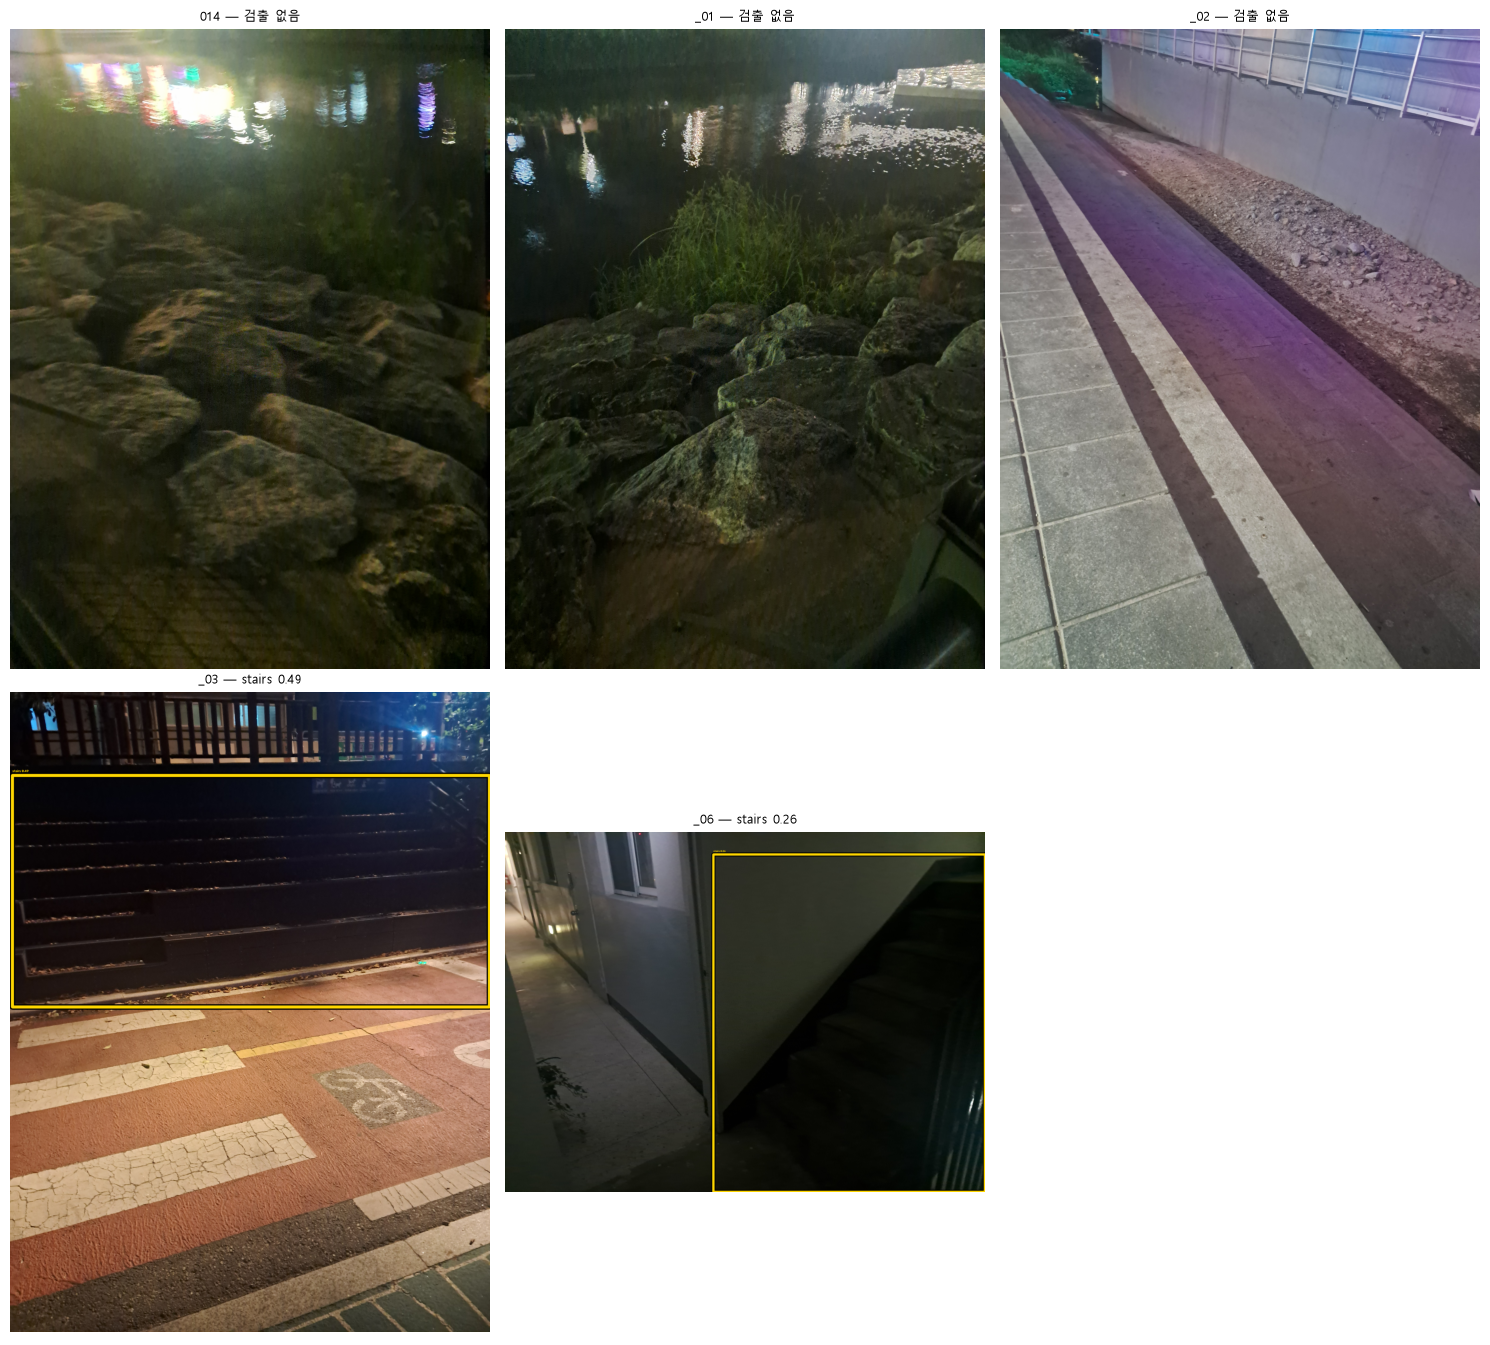

In [5]:
def grid(paths, ncols=3, width=5, conf=CONF):
    """배치로 한 번에 추론하고 ④ 강조 렌더로 그린다 (제품 화면과 같은 모습)."""
    results = predict(paths, conf)
    n = len(paths)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(width * ncols, width * nrows * 1.35))
    flat = np.ravel(np.array(axes, dtype=object))
    for ax, p, r in zip(flat, paths, results):
        dets = from_ultralytics(r, min_conf=conf)
        out = draw_emphasis(imread(p), dets, min_conf=conf, labels=True)
        ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        tag = ' · '.join(f'{d.name} {d.conf:.2f}' for d in dets) or '검출 없음'
        ax.set_title(f'{p.stem[-3:]} — {tag}', fontsize=9)
        ax.axis('off')
    for ax in flat[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


negs = [p for p in images('.') if scene_of(p.stem) == 'negative']
print(f'음성 {len(negs)}장 (원본 밝기) — 나온 박스는 전부 오탐')
grid(negs)


## 3. `_04` — 프로젝트 유일의 야간 볼라드 (정답 2개)

⚠️ **볼라드는 박스별로 봐야 한다.** 장면 단위 `maxconf` 만 보면 먼 쪽(밝고 안정)에 가려
가까운 쪽의 confidence 붕괴가 **안 보인다** — 인수분 계보(`c4d`)에서 실제로 그랬다.

> ⚠️ **박스별 conf 는 레터박스에 따라 ±0.02 흔들린다** (→ 함정 10). `docs/detection.md`
> 11-3c 의 `0.759 / 0.785 / 0.804` 는 **단일 이미지** 호출로 잰 값이고, 아래는 **7장 배치**
> 값이라 조금 다르다. **보는 것은 절대값이 아니라 '어두워져도 안 무너진다'는 방향이다.**


밝기,원본,gain0.35,gain0.20
볼라드,,,
가까운,0.779,0.801,0.812
먼,0.845,0.841,0.824


검출 수: {'원본': 2, 'gain0.35': 2, 'gain0.20': 2} (정답 2)

비교 — c4d_11n_640 의 가까운 볼라드: 0.595 -> 0.442 -> 0.321 (붕괴)
       c4d_11s_640              : 0.349 -> 미검출 -> 0.221


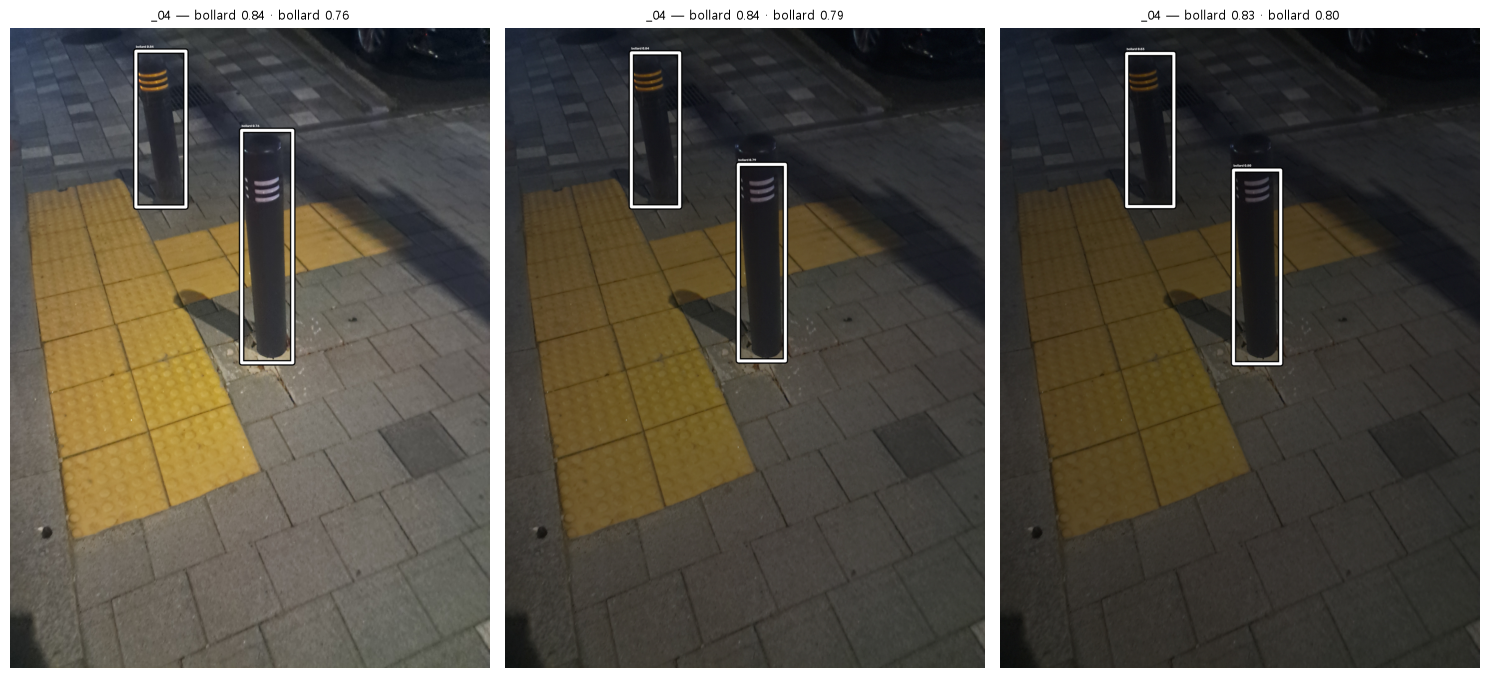

In [6]:
bollard_paths = {b: [p for p in images(sub) if scene_of(p.stem) == 'bollard'][0]
                 for b, sub in BRIGHTNESS.items()}

rec = []
# ⚠️ 밝기별로 **그 밝기의 7장 배치** 안에서 추론해야 문서 수치와 같다 (함정 10)
for bright, sub in BRIGHTNESS.items():
    paths = images(sub)
    r = dict(zip(paths, predict(paths)))[bollard_paths[bright]]
    items = [((bb[1] + bb[3]) / 2, float(c))
             for cid, c, bb in zip(r.boxes.cls.tolist(), r.boxes.conf.tolist(),
                                   r.boxes.xyxy.tolist()) if int(cid) == 2]
    items.sort(reverse=True)          # y 큰 쪽 = 화면 아래 = 가까운 볼라드
    for i, (y, c) in enumerate(items):
        rec.append({'밝기': bright, '볼라드': '가까운' if i == 0 else '먼',
                    'y중심': round(y), 'conf': round(c, 3)})

bdf = pd.DataFrame(rec)
display(bdf.pivot(index='볼라드', columns='밝기', values='conf')[list(BRIGHTNESS)])
print('검출 수:', bdf.groupby('밝기').size().reindex(list(BRIGHTNESS)).to_dict(), '(정답 2)')
print()
print('비교 — c4d_11n_640 의 가까운 볼라드: 0.595 -> 0.442 -> 0.321 (붕괴)')
print('       c4d_11s_640              : 0.349 -> 미검출 -> 0.221')
grid(list(bollard_paths.values()), ncols=3)


## 4. `_05` — 계단

현 배포(`c4b_loli0`)는 이 장면에서 계단 1개를 **2개로 과검출**했다.


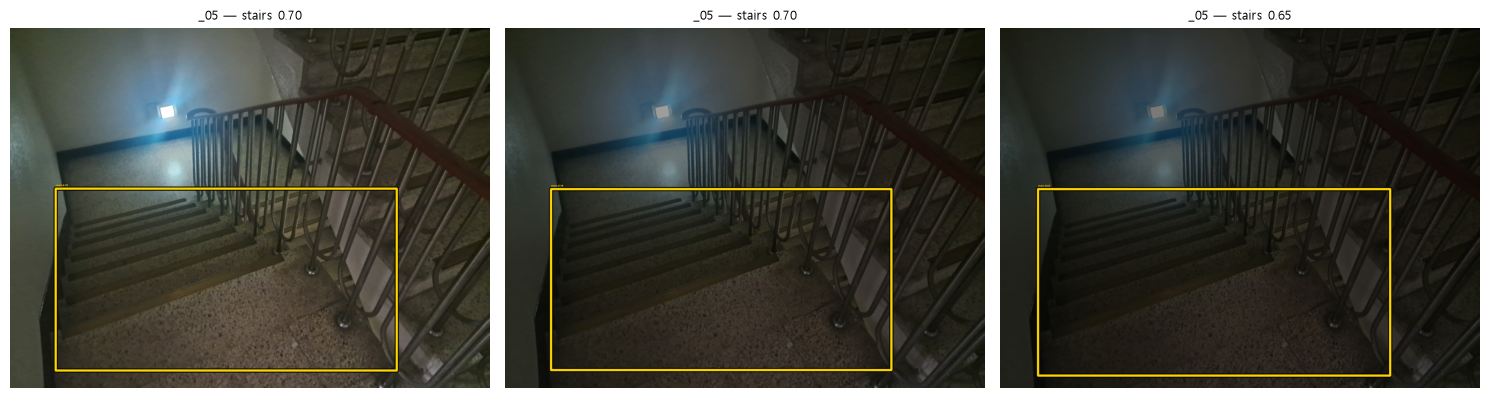

In [7]:
stair_paths = {b: [p for p in images(sub) if scene_of(p.stem) == 'stairs'][0]
               for b, sub in BRIGHTNESS.items()}
grid(list(stair_paths.values()), ncols=3)


## 5. conf 를 낮추면 — 왜 0.25 를 유지하는가

인수분은 **주간** 기준으로 conf 0.10 을 '무릎'이라 했지만, 보행 시점 실야간에서는
같은 하향에 `stairs` 오탐이 크게 뛴다. 시간축(트래킹·hold)으로도 흡수되지 않는다 —
오히려 오탐이 화면에 **더 오래 붙어 있다** (`docs/detection.md` 9-9-2).


In [8]:
sweep = []
for c in (0.25, 0.10, 0.05):
    for bright, sub in BRIGHTNESS.items():
        tot = {k: 0 for k in CLASS_NAMES.values()}
        hit = 0
        paths = images(sub)
        for p, r in zip(paths, predict(paths, c)):
            if scene_of(p.stem) != 'negative':
                continue
            hit += len(r.boxes) > 0
            for cid in r.boxes.cls.tolist():
                tot[CLASS_NAMES[int(cid)]] += 1
        sweep.append({'conf': c, '밝기': bright, **tot, '발화장수': hit})

sdf = pd.DataFrame(sweep).groupby('conf')[['person', 'stairs', 'bollard', '발화장수']].sum()
sdf.index.name = 'conf (음성 15프레임 합계)'
display(sdf)
print('현 배포 c4b_loli0: 6 -> 22 -> 34박스 (3.7배). 이 모델이 훨씬 완만하다.')


,person,stairs,bollard,발화장수
conf (음성 15프레임 합계),,,,
0.05,0,17,1,11
0.10,0,9,0,6
0.25,0,5,0,5


현 배포 c4b_loli0: 6 -> 22 -> 34박스 (3.7배). 이 모델이 훨씬 완만하다.


## 6. 동영상 — 보행 중 흔들림에서 어떤가

동영상 5개는 **전부 음성**이다 (계단·볼라드·사람 없음). 나오는 박스는 전부 오탐이다.


In [9]:
STRIDE, MAXF = 30, 12
vrows = []
for v in sorted(SRC.glob('*.mp4')):
    cap = cv2.VideoCapture(str(v))
    tot = {k: 0 for k in CLASS_NAMES.values()}
    used = i = 0
    while used < MAXF:
        ok, frame = cap.read()
        if not ok:
            break
        if i % STRIDE == 0:
            r = model.predict(frame, conf=CONF, imgsz=IMGSZ, device=0, verbose=False)[0]
            for cid in r.boxes.cls.tolist():
                tot[CLASS_NAMES[int(cid)]] += 1
            used += 1
        i += 1
    cap.release()
    vrows.append({'영상': v.stem[-6:], '샘플 프레임': used, **tot})

display(pd.DataFrame(vrows))


,영상,샘플 프레임,person,stairs,bollard
0,233004,6,1,4,3
1,238859,2,0,3,0
2,239174,7,0,6,0
3,243637,4,0,2,7
4,246347,4,1,0,6


## 7. 배포물(ONNX) 확인 — 계약이 실제로 3클래스인가

⚠️ `.pt` 와 ONNX 를 **파일 경로로** 비교하면 안 된다 — ultralytics 가 `.pt` 에는 가변
rect 레터박스를, 고정 shape ONNX 에는 640×640 을 먹여 **전처리가 달라진다**
(→ STATUS 3장 함정 10). 정합성은 `export_onnx.py` 가 미리 레터박스한 배열로 이미
검증했다(좌표 0.0001px · 신뢰도 0). 여기서는 **출력 계약만** 확인한다.


In [10]:
import onnxruntime as ort

if ONNX.is_file():
    sess = ort.InferenceSession(str(ONNX), providers=['CPUExecutionProvider'])
    i0, o0 = sess.get_inputs()[0], sess.get_outputs()[0]
    print(f'입력  {i0.name} {i0.shape} {i0.type}')
    print(f'출력  {o0.name} {o0.shape} {o0.type}')
    nc = o0.shape[1] - 4
    print()
    print(f'점수 채널 {nc}개 -> 클래스 {nc}종', 'OK' if nc == 3 else '기대와 다름')
    print('기존 2클래스 배포판은 [1, 6, 8400] 이었다 — 앱 후처리의 argmax 범위가 바뀐다.')
else:
    print(f'ONNX 없음: {ONNX}')
    print('생성:')
    print('  uv run python scripts/export_onnx.py \\')
    print('      --weights outputs/detect/c4e_s3_11n/weights/best.pt \\')
    print('      --val-images "D:/datasets/_derived/detect_v3/images/val"')


입력  images [1, 3, 640, 640] tensor(float)
출력  output0 [1, 7, 8400] tensor(float)

점수 채널 3개 -> 클래스 3종 OK
기존 2클래스 배포판은 [1, 6, 8400] 이었다 — 앱 후처리의 argmax 범위가 바뀐다.


---

## 정리 — 이 노트북이 보여 준 것

| | |
|---|---|
| ✅ **야간 볼라드** | 세 밝기 전부 2/2 검출 · 가까운 쪽 confidence 가 어두워져도 **안 무너진다** |
| ✅ **`stairs` 오탐** | 현 배포보다 적고, conf 하향의 대가도 완만하다 |
| ✅ **`person` 오탐** | 사람이 없는 야간 노면에서 헛보지 않는다 |
| 🔴 **④ `bollard` 색** | `PALETTE` 에 없어 **흰색**으로 그려진다 — 위 그림에 그대로 보인다. 저시력 사용자에게 색 구분은 **기능 요건**이라 앱 적용 전에 정해야 한다 |

### 그리고 이것은 판정이 아니다

- 음성 **5장** · 야간 볼라드 **1장** · **seed 1개**
- 밝기 2단은 **합성본**이라 밝기 축 자체는 근거로 못 쓴다
- 라벨이 없어 **recall·FP 를 못 센다**

**→ 최종 채택 판정은 `C5`(자체 촬영 야간 평가셋)이다.**
